## A. 
Data Preparation (0.5p): Load the weather time series dataset. For instance the Jena climate dataset,
you can obtain it by running curl https://www.bgc-jena.mpg.de/wetter/mpi saale 2021b.zip -o
mpi saale 2021b.zip. This is likely a multivariate time series (e.g., temperature, pressure, humidity,
etc.). For the forecasting task, choose one target variable to predict (e.g., daily temperature). Define the
forecasting horizon (e.g., predict the next 7 days of the target given the past 30 days of data). Split the
data into training/validation/test segments by date

Raw data: 26496 rows, 30 variables
Hourly rows: 4417; variables: 30
Data range: 2021-07-01 to 2022-01-01
Target: T (degC)
Forecasting setup: past 30 hours -> next 1 hour
Feature tensor shape: (4387, 30, 30) = (samples, timesteps, features)
Target tensor shape: (4387, 1) = (samples, forecast_steps)
Train: (3061, 30, 30), horizons ending 2021-07-02 to 2021-11-06
Val:   (663, 30, 30), horizons ending 2021-11-06 to 2021-12-04
Test:  (663, 30, 30), horizons ending 2021-12-04 to 2022-01-01


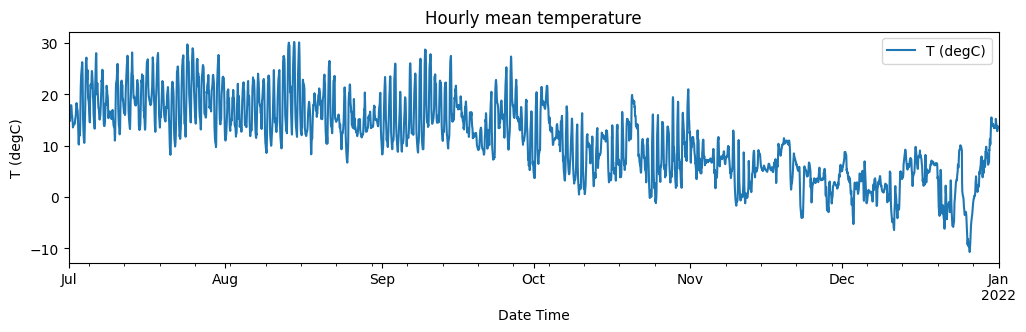

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


DATA_DIR = Path.cwd()
CSV_PATH = DATA_DIR / "mpi_saale_2021b.csv"

TARGET = "T (degC)"
INPUT_HOURS = 30
FORECAST_HORIZON_HOURS = 1
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15


weather_raw = pd.read_csv(CSV_PATH, sep=",", skipinitialspace=True)
weather_raw.columns = [c.strip().strip('"') for c in weather_raw.columns]
weather_raw["Date Time"] = pd.to_datetime(
    weather_raw["Date Time"], format="%d.%m.%Y %H:%M:%S"
)
weather_raw = weather_raw.set_index("Date Time").sort_index()
weather_raw = weather_raw.apply(pd.to_numeric, errors="coerce")

hourly = weather_raw.resample("1h").mean(numeric_only=True)
hourly = hourly.interpolate(limit_direction="both").dropna(axis=1, how="any")
weather_daily = hourly

n_hours = len(hourly)
train_end = int(n_hours * TRAIN_SPLIT)
val_end = int(n_hours * (TRAIN_SPLIT + VAL_SPLIT))

train_df = hourly.iloc[:train_end]
val_df = hourly.iloc[train_end:val_end]
test_df = hourly.iloc[val_end:]

feature_columns = hourly.columns.tolist()
target_index = feature_columns.index(TARGET)
feature_mean = train_df.mean()
feature_std = train_df.std().replace(0, 1)
feature_scaler = StandardScaler().fit(train_df)
target_scaler = StandardScaler().fit(train_df[[TARGET]])
scaled_features = feature_scaler.transform(hourly)
scaled_target = target_scaler.transform(hourly[[TARGET]]).ravel()


def make_sequences(
    values: np.ndarray,
    target: np.ndarray,
    dates: pd.Index,
    lookback: int,
    horizon: int,
):
    X, y, y_dates = [], [], []
    for end in range(lookback, len(values) - horizon + 1):
        target_idx = end + horizon - 1
        X.append(values[end - lookback:end])
        y.append(target[target_idx])
        y_dates.append(dates[target_idx])
    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32).reshape(-1, 1),
        pd.DatetimeIndex(y_dates),
    )


X, y, target_dates = make_sequences(
    scaled_features, scaled_target, hourly.index, INPUT_HOURS, FORECAST_HORIZON_HOURS
)

split_dates = hourly.index[INPUT_HOURS + FORECAST_HORIZON_HOURS - 1 :]
train_end_idx = int(len(split_dates) * TRAIN_SPLIT) - 1
val_end_idx = int(len(split_dates) * (TRAIN_SPLIT + VAL_SPLIT)) - 1
TRAIN_END = split_dates[train_end_idx].strftime("%Y-%m-%d")
VAL_END = split_dates[val_end_idx].strftime("%Y-%m-%d")

train_mask = target_dates < hourly.index[train_end]
val_mask = (target_dates >= hourly.index[train_end]) & (target_dates < hourly.index[val_end])
test_mask = target_dates >= hourly.index[val_end]

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
dates_train = target_dates[train_mask]
dates_val = target_dates[val_mask]
dates_test = target_dates[test_mask]
test_dates = dates_test

print(f"Raw data: {weather_raw.shape[0]} rows, {weather_raw.shape[1]} variables")
print(f"Hourly rows: {n_hours}; variables: {hourly.shape[1]}")
print(f"Data range: {hourly.index.min().date()} to {hourly.index.max().date()}")
print(f"Target: {TARGET}")
print(f"Forecasting setup: past {INPUT_HOURS} hours -> next {FORECAST_HORIZON_HOURS} hour")
print(f"Feature tensor shape: {X.shape} = (samples, timesteps, features)")
print(f"Target tensor shape: {y.shape} = (samples, forecast_steps)")
print(f"Train: {X_train.shape}, horizons ending {dates_train.min().date()} to {dates_train.max().date()}")
print(f"Val:   {X_val.shape}, horizons ending {dates_val.min().date()} to {dates_val.max().date()}")
print(f"Test:  {X_test.shape}, horizons ending {dates_test.min().date()} to {dates_test.max().date()}")

hourly[[TARGET]].plot(figsize=(12, 3), title="Hourly mean temperature")
plt.ylabel(TARGET)
plt.show()


## B.
Implement LSTM Model (0.5p): Using your chosen framework, define an LSTM-based neural network
for forecasting the next time step. (Tip: In Keras you can use tf.keras.layers.LSTM, and in PyTorch
use torch.nn.LSTM within a custom nn.Module). Include necessary layers (e.g., one or two LSTM layers
followed by a dense output layer). Choose a loss function such as Mean Squared Error and an optimizer
(e.g., Adam). Train the LSTM model on the training set. Monitor the training and validation loss over
epochs to ensure the model is learning (you may use early stopping to prevent overfitting)

In [2]:
import copy

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=16,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=16,
)


In [3]:
DROPOUT = 0.2
EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=0.001,
    patience=EARLY_STOPPING_PATIENCE,
):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    best_val_loss = np.inf
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                val_loss = criterion(model(batch_X), batch_y)
                val_losses.append(val_loss.item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history.append({"epoch": epoch + 1, "loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val_loss - 1e-7:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history)


In [4]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=32, num_layers=2, output_size=FORECAST_HORIZON_HOURS, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        return self.linear(self.dropout(hidden[-1]))


lstm_model = LSTMForecaster(n_features=X_train.shape[2], hidden_size=32, num_layers=2)
history_lstm = train_model(lstm_model, train_loader, val_loader)
print(lstm_model)
history_lstm.tail()


LSTMForecaster(
  (lstm): LSTM(30, 32, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)


,epoch,loss,val_loss
19,20,0.029933,0.159107
20,21,0.029690,0.036023
21,22,0.026559,0.069056
22,23,0.029675,0.084150
23,24,0.028627,0.058389


## C.
Implement GRU Model (0.5p): Define a similar neural network using Gated Recurrent Unit layers (tf.keras.layers.GRU
or torch.nn.GRU). Ensure it has a comparable number of parameters to the LSTM model for a fair com-
parison (adjust the number of units if needed). Train the GRU model on the same training data, using the
same training procedure and epochs as the LSTM.

In [5]:
class GRUForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=38, num_layers=2, output_size=FORECAST_HORIZON_HOURS, dropout=DROPOUT):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, hidden = self.gru(x)
        return self.linear(self.dropout(hidden[-1]))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


gru_model = GRUForecaster(n_features=X_train.shape[2], hidden_size=38, num_layers=2)

print(f"LSTM parameters: {count_parameters(lstm_model):,}")
print(f"GRU parameters:  {count_parameters(gru_model):,}")

history_gru = train_model(gru_model, train_loader, val_loader)
print(gru_model)
history_gru.tail()


LSTM parameters: 16,673
GRU parameters:  16,911
GRUForecaster(
  (gru): GRU(30, 38, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=38, out_features=1, bias=True)
)


,epoch,loss,val_loss
18,19,0.027204,0.026549
19,20,0.027743,0.051103
20,21,0.026080,0.030068
21,22,0.027030,0.049451
22,23,0.026180,0.024799


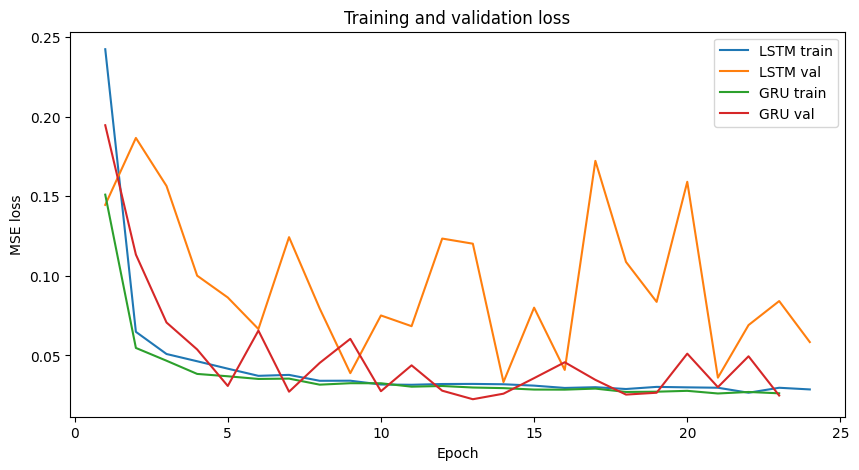

In [6]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plt.plot(history_lstm["epoch"], history_lstm["loss"], label="LSTM train")
plt.plot(history_lstm["epoch"], history_lstm["val_loss"], label="LSTM val")
plt.plot(history_gru["epoch"], history_gru["loss"], label="GRU train")
plt.plot(history_gru["epoch"], history_gru["val_loss"], label="GRU val")
plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()


## D.
Evaluation (1p): For both models, forecast the next time step for each sequence in the test set. Compute
error metrics on the test data, including Mean Absolute Error (MAE) and Root Mean Squared Error
(RMSE).

In [7]:
test_X_tensor = torch.tensor(X_test)

lstm_model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_pred_scaled = lstm_model(test_X_tensor).numpy()
    gru_pred_scaled = gru_model(test_X_tensor).numpy()

target_mean = feature_mean[TARGET]
target_std = feature_std[TARGET]

y_test_c = y_test * target_std + target_mean
lstm_pred_c = lstm_pred_scaled * target_std + target_mean
gru_pred_c = gru_pred_scaled * target_std + target_mean


def regression_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse


lstm_mae, lstm_rmse = regression_metrics(y_test_c, lstm_pred_c)
gru_mae, gru_rmse = regression_metrics(y_test_c, gru_pred_c)

results = pd.DataFrame({
    "model": ["LSTM", "GRU"],
    "MAE (degC)": [lstm_mae, gru_mae],
    "RMSE (degC)": [lstm_rmse, gru_rmse],
})

results


,model,MAE (degC),RMSE (degC)
0,LSTM,1.536027,2.020621
1,GRU,1.108420,1.732923


## E.
Hyperparameter Experiments (1p): Perform at least one hyperparameter variation for each model. For
example, train a second LSTM with a different number of units or an extra LSTM layer, and note the
impact on performance. Do the same for GRU (or vary learning rate, batch size, etc.). This will illustrate
sensitivity to hyperparameters.

In [8]:
def evaluate_model(model):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(test_X_tensor).numpy()
    pred_c = pred_scaled * target_std + target_mean
    return regression_metrics(y_test_c, pred_c)


lstm_model_v2 = LSTMForecaster(n_features=X_train.shape[2], hidden_size=64*2)
gru_model_v2 = GRUForecaster(n_features=X_train.shape[2], hidden_size=64*2)

history_lstm_v2 = train_model(lstm_model_v2, train_loader, val_loader)
history_gru_v2 = train_model(gru_model_v2, train_loader, val_loader)

lstm_v2_mae, lstm_v2_rmse = evaluate_model(lstm_model_v2)
gru_v2_mae, gru_v2_rmse = evaluate_model(gru_model_v2)

experiment_results = pd.DataFrame({
    "model": ["LSTM V1", "LSTM V2", "GRU V1", "GRU V2"],
    "parameters": [
        count_parameters(lstm_model),
        count_parameters(lstm_model_v2),
        count_parameters(gru_model),
        count_parameters(gru_model_v2),
    ],
    "best val loss": [
        history_lstm["val_loss"].min(),
        history_lstm_v2["val_loss"].min(),
        history_gru["val_loss"].min(),
        history_gru_v2["val_loss"].min(),
    ],
    "MAE (degC)": [lstm_mae, lstm_v2_mae, gru_mae, gru_v2_mae],
    "RMSE (degC)": [lstm_rmse, lstm_v2_rmse, gru_rmse, gru_v2_rmse],
})

experiment_results


,model,parameters,best val loss,MAE (degC),RMSE (degC)
0,LSTM V1,16673,0.033240,1.536027,2.020621
1,LSTM V2,214145,0.018640,0.943299,1.326936
2,GRU V1,16911,0.022474,1.108420,1.732923
3,GRU V2,160641,0.023706,1.039446,1.528785


## F.
isualization (0.5p): Plot the model predictions vs. actual values on the test set for a visual comparison.
Create a line plot for a subset of the test period (e.g., last 30 days) showing true vs predicted values for
each model. This helps interpret where the model is performing well or failing (e.g., does it capture trends
or miss sudden changes?)

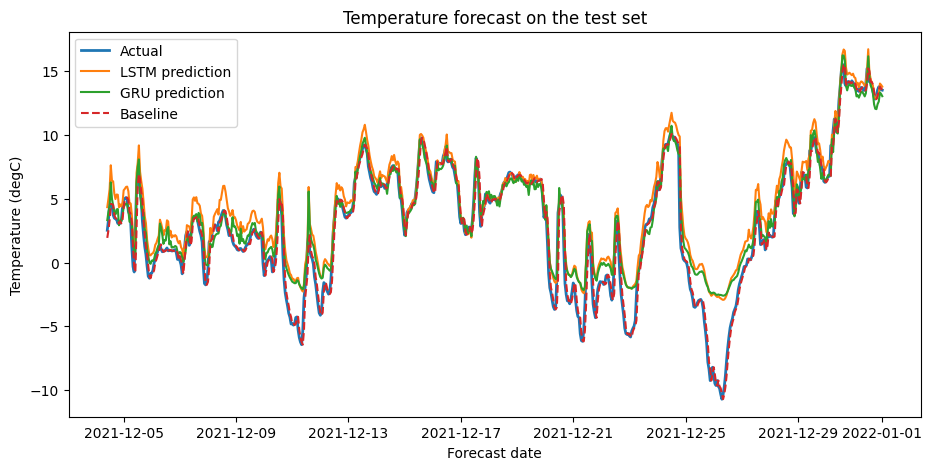

In [9]:
import matplotlib.pyplot as plt


forecast_dates = np.array([
    [end_date - pd.Timedelta(days=FORECAST_HORIZON_HOURS - 1 - step) for step in range(FORECAST_HORIZON_HOURS)]
    for end_date in dates_test
])

plot_data = pd.DataFrame({
    "date": forecast_dates.ravel(),
    "actual": y_test_c.ravel(),
    "LSTM": lstm_pred_c.ravel(),
    "GRU": gru_pred_c.ravel(),
}).groupby("date").mean()
baseline = weather_daily[TARGET].shift(1).reindex(plot_data.index)

plt.figure(figsize=(11, 5))
plt.plot(plot_data.index, plot_data["actual"], label="Actual", linewidth=2)
plt.plot(plot_data.index, plot_data["LSTM"], label="LSTM prediction")
plt.plot(plot_data.index, plot_data["GRU"], label="GRU prediction")
plt.plot(plot_data.index, baseline, label="Baseline", linestyle="--")
plt.title("Temperature forecast on the test set")
plt.xlabel("Forecast date")
plt.ylabel("Temperature (degC)")
plt.legend()
plt.show()


## G.
Interpretability Discussion (1p): Although LSTMs and GRUs are black-box models, examine their internal
behavior if possible. For instance, you can plot the values of the LSTM forget gate over time for a test
sequence to see how it modulates information, or analyze which input timesteps had the most influence
on the prediction (e.g., by partial input perturbation). Discuss any insight gained about how the model is
making decisions.

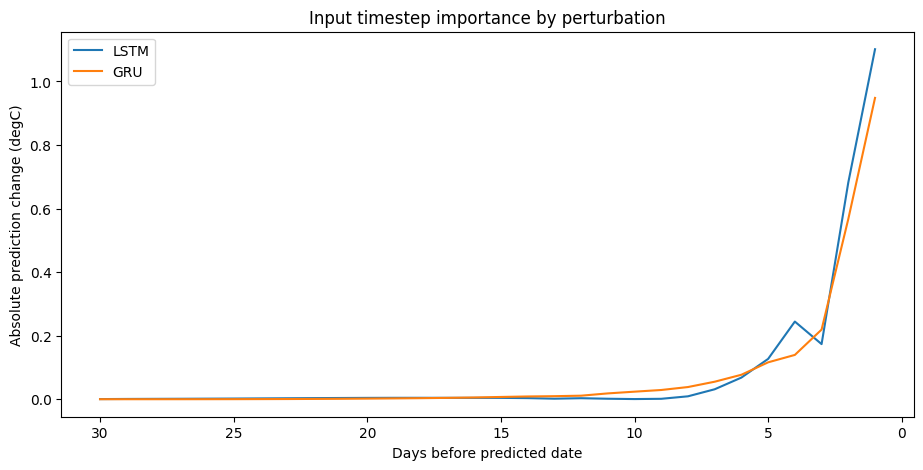

,days before prediction,LSTM importance (degC),GRU importance (degC)
29,1,1.101453,0.948262
28,2,0.682224,0.567263
26,4,0.244400,0.139479
27,3,0.173507,0.219126
25,5,0.126963,0.116155


In [12]:
def timestep_importance(model, sequence):
    model.eval()
    base_sequence = torch.tensor(sequence[None, :, :])
    with torch.no_grad():
        base_prediction = model(base_sequence).numpy()[0]

    changes = []
    for t in range(sequence.shape[0]):
        changed_sequence = sequence.copy()
        changed_sequence[t, :] = 0.0
        changed_sequence = torch.tensor(changed_sequence[None, :, :])
        with torch.no_grad():
            changed_prediction = model(changed_sequence).numpy()[0]
        changes.append(np.mean(np.abs(base_prediction - changed_prediction)) * target_std)

    return np.array(changes)


sequence_id = -1
test_sequence = X_test[sequence_id]
lag_days = np.arange(INPUT_HOURS, 0, -1)

lstm_importance = timestep_importance(lstm_model, test_sequence)
gru_importance = timestep_importance(gru_model, test_sequence)

importance = pd.DataFrame({
    "days before prediction": lag_days,
    "LSTM importance (degC)": lstm_importance,
    "GRU importance (degC)": gru_importance,
})

plt.figure(figsize=(11, 5))
plt.plot(importance["days before prediction"], importance["LSTM importance (degC)"], label="LSTM")
plt.plot(importance["days before prediction"], importance["GRU importance (degC)"], label="GRU")
plt.gca().invert_xaxis()
plt.title("Input timestep importance by perturbation")
plt.xlabel("Days before predicted date")
plt.ylabel("Absolute prediction change (degC)")
plt.legend()
plt.show()

importance.sort_values("LSTM importance (degC)", ascending=False).head()


## Baseline Benchmark
Compute a simple baseline forecast (e.g., “naive” forecast where the prediction is just
the last observed value, or a basic linear regression on the last few lags). Compare the deep models’ performance
to this baseline to quantify the value they add.

In [11]:
persistence_pred_scaled = np.repeat(X_test[:, -1, target_index, None], FORECAST_HORIZON_HOURS, axis=1)
persistence_pred_c = persistence_pred_scaled * target_std + target_mean

persistence_mae, persistence_rmse = regression_metrics(y_test_c, persistence_pred_c)

baseline_comparison = pd.DataFrame({
    "model": ["Baseline", "LSTM", "GRU"],
    "MAE (degC)": [persistence_mae, lstm_mae, gru_mae],
    "RMSE (degC)": [persistence_rmse, lstm_rmse, gru_rmse],
})

baseline_comparison


,model,MAE (degC),RMSE (degC)
0,Baseline,0.539391,0.831401
1,LSTM,1.536027,2.020621
2,GRU,1.108420,1.732923
